
# Kienzle Milling Model – Time-Based Implementation

This notebook implements the Kienzle cutting force and torque model for **milling**, where each tooth contributes according to its instantaneous angular position:

$$
\phi_j(t) = \omega t + (j-1) \frac{2\pi}{z}
$$

The model follows your Stan formulation:

$$
T_c(t) = a_p\, f_z^{1-m_c}\, \sin(\kappa)^{1-m_c} \, k_{c11} \, r_{tool} \, 
\sum_{j \in \text{engaged}} \sin(\phi_j(t))^{1-m_c}
$$

This notebook computes:

- Spindle angle over time
- Engagement of each cutting edge between entry/exit angles
- Cutting force time series
- Torque time series


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def kienzle_milling_force_torque_time(
        t,          # time vector [s]
        ap,         # depth of cut [mm]
        fz,         # feed per tooth [mm]
        z,          # number of cutting edges
        kappa,      # tool angle [rad]
        omega,      # spindle angular velocity [rad/s]
        kc11,       # specific cutting force
        mc,         # Kienzle exponent
        rtool,      # tool radius [m]
        phi_ent,    # entry angle [rad]
        phi_exit    # exit angle [rad]
    ):
    """ Kienzle milling model (time-domain). """

    t = np.asarray(t)
    n = t.size

    # Base spindle angle
    phi = omega * t

    # Tooth angular offsets
    tooth_offsets = np.arange(z) * 2.0 * np.pi / z

    # Full angle matrix
    angles = phi[:, None] + tooth_offsets[None, :]
    angles = (angles + 2*np.pi) % (2*np.pi)

    # Engagement check
    engaged = (angles >= phi_ent) & (angles <= phi_exit)

    # Sin contributions
    sin_term = np.abs(np.sin(angles)) ** (1.0 - mc)
    sin_term *= engaged

    sin_sums = np.sum(sin_term, axis=1)

    base = ap * (fz ** (1.0 - mc)) * np.sin(kappa) ** (1.0 - mc) * kc11

    Fc = base * sin_sums
    Tc = Fc * rtool

    return phi, Fc, Tc, sin_sums



## Example Simulation

We simulate a 4‑flute end mill at 6000 rpm cutting for 0.1 s.


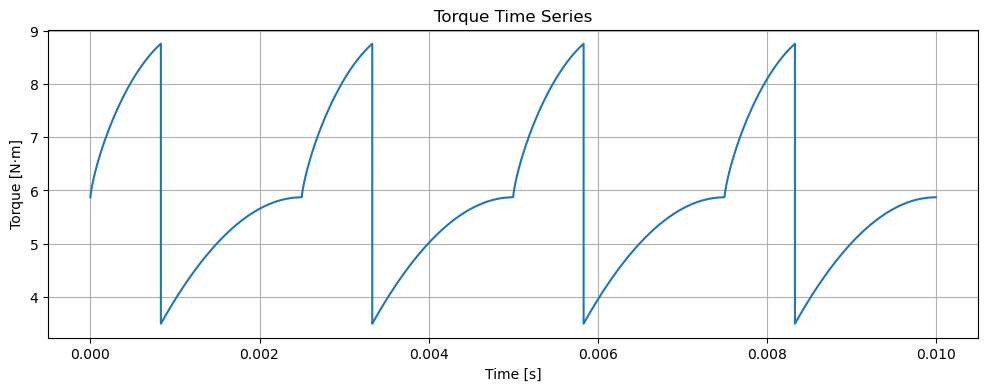

In [5]:

import numpy as np
import matplotlib.pyplot as plt

# Example parameters
ap = 2.0       # mm
fz = 0.05      # mm/tooth
z = 4
kappa = np.deg2rad(45)
n_rpm = 6000
omega = 2 * np.pi * n_rpm / 60
kc11 = 1800    # example value
mc = 0.25
rtool = 0.02   # 20 mm radius
phi_ent = np.deg2rad(0.0)
phi_exit = np.deg2rad(120)

# Time vector
t = np.linspace(0, 0.01, 200000)

phi, Fc, Tc, sin_sums = kienzle_milling_force_torque_time(
    t, ap, fz, z, kappa, omega, kc11, mc, rtool, phi_ent, phi_exit
)

plt.figure(figsize=(12,4))
plt.plot(t, Tc)
plt.title("Torque Time Series")
plt.xlabel("Time [s]")
plt.ylabel("Torque [N·m]")
plt.grid(True)
plt.show()


In [ ]:
## read in the process parameters from a excel file
tool_type = 'C1030' # insert tool type here C4240
param_experim_data_file = f'../../../data/parameterize_experiment/Experiment_{tool_type}.xlsx'
params_df = pd.read_excel(param_experim_data_file, index_col=0)


In [ ]:
def get_output_angle(ae, rtool):
    """ Get output angle with given entrance angle 0 [rad]. """
    dtool = 2 * rtool
    if (ae > dtool):
        raise ValueError("ae cannot be larger than tool diameter")
    if(ae>=rtool):
        kath = rtool-(dtool-ae)
        phi_out = np.pi - np.arccos(kath/rtool)
    else:
        kath = rtool - ae
        phi_out = np.arccos(kath/rtool)
    return phi_out

In [ ]:
pp = get_output_angle(10/1000, rtool)
print(f'tool diameter: {2*rtool} mm')
pp*180/np.pi

tool diameter: 0.04 mm


60.00000000000001

In [ ]:
params_df

,Ae (mm),Ap (mm),f (mm/min),N (rpm),SinuTraceFile (*.csv)
No,,,,,
1,40,1.0,632.00,2108.0,Trace_0622_172347.csv
2,38,1.0,632.00,2108.0,Trace_0622_172531.csv
3,32,1.0,632.00,2108.0,Trace_0622_172702.csv
4,26,1.0,632.00,2108.0,Trace_0622_172811.csv
5,40,1.0,632.00,2108.0,Trace_0622_173003.csv
...,...,...,...,...,...
68,26,1.0,758.88,2529.6,Trace_0623_155720.csv
69,40,1.0,568.80,2149.0,Trace_0623_155849.csv
70,38,1.0,568.80,2149.0,Trace_0623_160007.csv


In [ ]:
params_df['phi_exit_rad'] = params_df.apply(
    lambda row: get_output_angle(row['Ae (mm)']/1000, rtool), axis=1
)
params_df['phi_ent_rad'] = np.deg2rad(0.0)  # assuming constant entry angle of 0 degree

params_df['rtool (m)'] = rtool
params_df['omega (rad/s)'] = 2 * np.pi * params_df['N (rpm)'] / 60
params_df['z'] = 2
params_df['kappa (rad)'] = np.deg2rad(45.0)  # assuming constant tool angle of 45 degree
params_df['kc11'] = 1800  # example value
params_df['mc'] = 0.25    # example value
params_df['fz (mm/tooth)'] = params_df['f (mm/min)']/(params_df['N (rpm)']*params_df['z'])  #  

In [ ]:
params_df

,Ae (mm),Ap (mm),f (mm/min),N (rpm),SinuTraceFile (*.csv),phi_exit_rad,phi_ent_rad,rtool (m),omega (rad/s),z,kappa (rad),kc11,mc,fz (mm/tooth)
No,,,,,,,,,,,,,,
1,40,1.0,632.00,2108.0,Trace_0622_172347.csv,3.141593,0.0,0.02,220.749244,2,0.785398,1800,0.25,0.149905
2,38,1.0,632.00,2108.0,Trace_0622_172531.csv,2.690566,0.0,0.02,220.749244,2,0.785398,1800,0.25,0.149905
3,32,1.0,632.00,2108.0,Trace_0622_172702.csv,2.214297,0.0,0.02,220.749244,2,0.785398,1800,0.25,0.149905
4,26,1.0,632.00,2108.0,Trace_0622_172811.csv,1.875489,0.0,0.02,220.749244,2,0.785398,1800,0.25,0.149905
5,40,1.0,632.00,2108.0,Trace_0622_173003.csv,3.141593,0.0,0.02,220.749244,2,0.785398,1800,0.25,0.149905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,26,1.0,758.88,2529.6,Trace_0623_155720.csv,1.875489,0.0,0.02,264.899093,2,0.785398,1800,0.25,0.150000
69,40,1.0,568.80,2149.0,Trace_0623_155849.csv,3.141593,0.0,0.02,225.042754,2,0.785398,1800,0.25,0.132341
70,38,1.0,568.80,2149.0,Trace_0623_160007.csv,2.690566,0.0,0.02,225.042754,2,0.785398,1800,0.25,0.132341


## Pipeline (Correct & Minimal)

For each row in your dataframe:

### Read the real data CSV from SinuTraceFile

This file contains the real spindle iq(t) and its time vector.

Let’s assume each file has:

- time (s)

- iq_spindle (A)

### Compute the time vector

Use the exact same timestamps as the real measurement:

This guarantees synchronisation of real vs simulated torque.

### Compute the model angular position
$$\phi(t)=\omega t$$

Given from dataframe:

### Compute the full Kienzle torque waveform

Using your corrected, physically valid model:

- entry angle: phi_ent_rad
- exit angle: phi_exit_rad
- number of teeth: z
- fz from your dataframe
- kc11, mc, ap

Output:
$$ T_c(t) $$


In [ ]:
df = params_df.copy()
results = []
tool_type = 'C1030'  # insert tool type here C4240
#param_experim_all_files = f'../../../data/parameterize_experiment/Experiment_{tool_type}.xlsx'
file_folder = f'../../../data/raw/{tool_type}/all/' #f'../../../data/raw/{tool_type}/all/'
#C:\Users\thmru\github\2025_LM_FinalProject\data\raw\C1030\all
for idx, row in df.iterrows():

    # 1. Read real measurement file
    file_path = file_folder + row["SinuTraceFile (*.csv)"]
    print(f"Processing measurement {idx}: {file_path}")
    real = pd.read_csv(file_path)
    t = real["time"].values
    iq_real = real["iqAx4"].values

    # 2. Extract parameters
    ap = row["Ap (mm)"]
    fz = row["fz (mm/tooth)"]                     # already in dataframe
    z  = int(row["z"])
    kappa = row["kappa (rad)"]
    omega = row["omega (rad/s)"]
    kc11 = row["kc11"]
    mc = row["mc"]
    rtool = row["rtool (m)"]
    phi_ent = row["phi_ent_rad"]
    phi_exit = row["phi_exit_rad"]

    # 3. Calculate model torque on same time stamps
    phi, Fc, Tc, sin_sums = kienzle_milling_force_torque_time(
        t, ap, fz, z, kappa, omega, kc11, mc, rtool, phi_ent, phi_exit
    )

    # 4. Create synchronized output dataframe
    out = pd.DataFrame({
        "time": t,
        "Tc_model": Tc,
        "Iq_real": iq_real,
        "phi": phi,
        "sin_sums": sin_sums,
        "measurement_id": idx
    })

    # 5. Save result file per measurement
    fname = f"../../../data/preprocessed/Mill/measurement_{idx:03d}_training_data.csv"
    out.to_csv(fname, index=False)

    results.append(fname)

results[:5]   # show first few generated files


Processing measurement 1: ../../../data/raw/C1030/all/Trace_0622_172347.csv
Processing measurement 2: ../../../data/raw/C1030/all/Trace_0622_172531.csv
Processing measurement 3: ../../../data/raw/C1030/all/Trace_0622_172702.csv
Processing measurement 4: ../../../data/raw/C1030/all/Trace_0622_172811.csv
Processing measurement 5: ../../../data/raw/C1030/all/Trace_0622_173003.csv
Processing measurement 6: ../../../data/raw/C1030/all/Trace_0622_173125.csv
Processing measurement 7: ../../../data/raw/C1030/all/Trace_0622_173849.csv
Processing measurement 8: ../../../data/raw/C1030/all/Trace_0622_174016.csv
Processing measurement 9: ../../../data/raw/C1030/all/Trace_0623_092954.csv
Processing measurement 10: ../../../data/raw/C1030/all/Trace_0623_093253.csv
Processing measurement 11: ../../../data/raw/C1030/all/Trace_0623_093518.csv
Processing measurement 12: ../../../data/raw/C1030/all/Trace_0623_093518.csv
Processing measurement 13: ../../../data/raw/C1030/all/Trace_0623_093804.csv
Processi

['../../../data/preprocessed/Mill/measurement_001_training_data.csv',
 '../../../data/preprocessed/Mill/measurement_002_training_data.csv',
 '../../../data/preprocessed/Mill/measurement_003_training_data.csv',
 '../../../data/preprocessed/Mill/measurement_004_training_data.csv',
 '../../../data/preprocessed/Mill/measurement_005_training_data.csv']

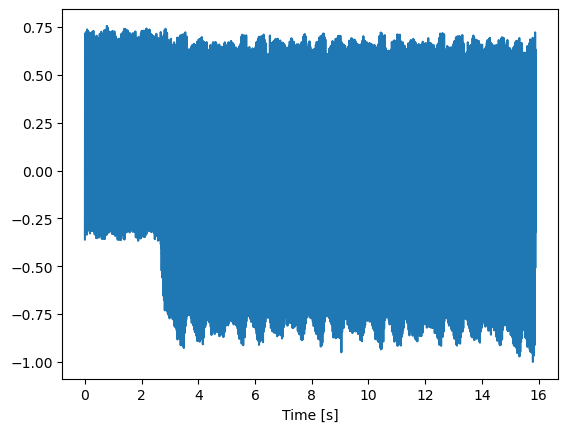

In [ ]:
plt.plot(t, Tc/np.max(Tc)-iq_real/np.max(iq_real))
plt.xlabel('Time [s]')    
plt.show()